# Brent Oil Prices — Data Preparation & EDA

Task 1 / Task 2.1: load the data, examine trend and volatility, overlay researched
key events, and test stationarity to motivate modeling log returns.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.stattools import adfuller

sys.path.append(str(Path.cwd().parent))
from src.data_loader import add_log_returns, load_events, load_prices

plt.rcParams["figure.figsize"] = (14, 5)

In [2]:
prices = add_log_returns(load_prices())
events = load_events()

print(f"{len(prices)} daily observations, {prices.index.min():%Y-%m-%d} to {prices.index.max():%Y-%m-%d}")
prices.head()

9011 daily observations, 1987-05-20 to 2022-11-14


,Price,LogReturn
Date,,
1987-05-20,18.63,NaN
1987-05-21,18.45,-0.009709
1987-05-22,18.55,0.005405
1987-05-25,18.60,0.002692
1987-05-26,18.63,0.001612


## Raw price series with key events overlaid

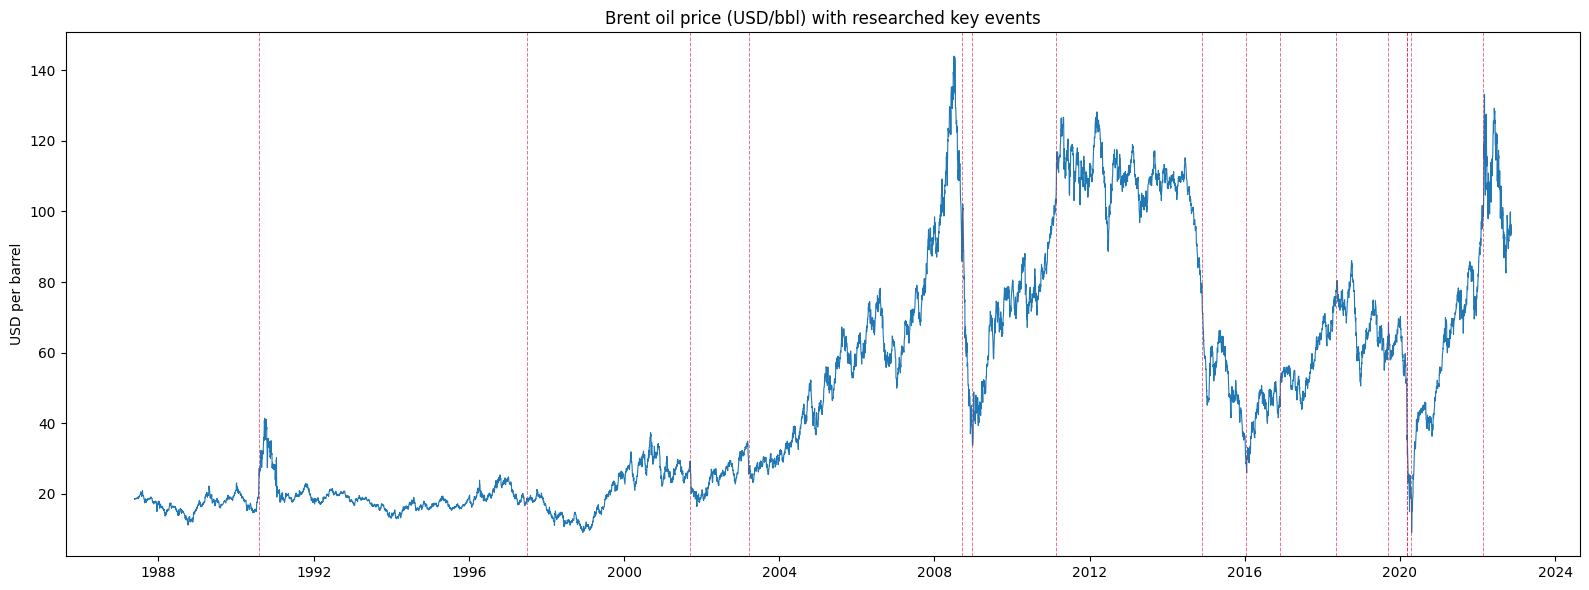

In [3]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(prices.index, prices["Price"], lw=0.8)
for _, ev in events.iterrows():
    ax.axvline(ev["event_date"], color="crimson", ls="--", lw=0.7, alpha=0.6)
ax.set_title("Brent oil price (USD/bbl) with researched key events")
ax.set_ylabel("USD per barrel")
plt.tight_layout()

## Trend: log scale and rolling annual mean

The level series spans ~$9 to ~$144, so a log scale shows relative moves across
eras more honestly. The 252-day rolling mean smooths daily noise and exposes the
broad regimes (pre-2000 low-price era, 2003–2008 run-up, 2011–2014 plateau,
2014–15 collapse, 2020 COVID crash and recovery).

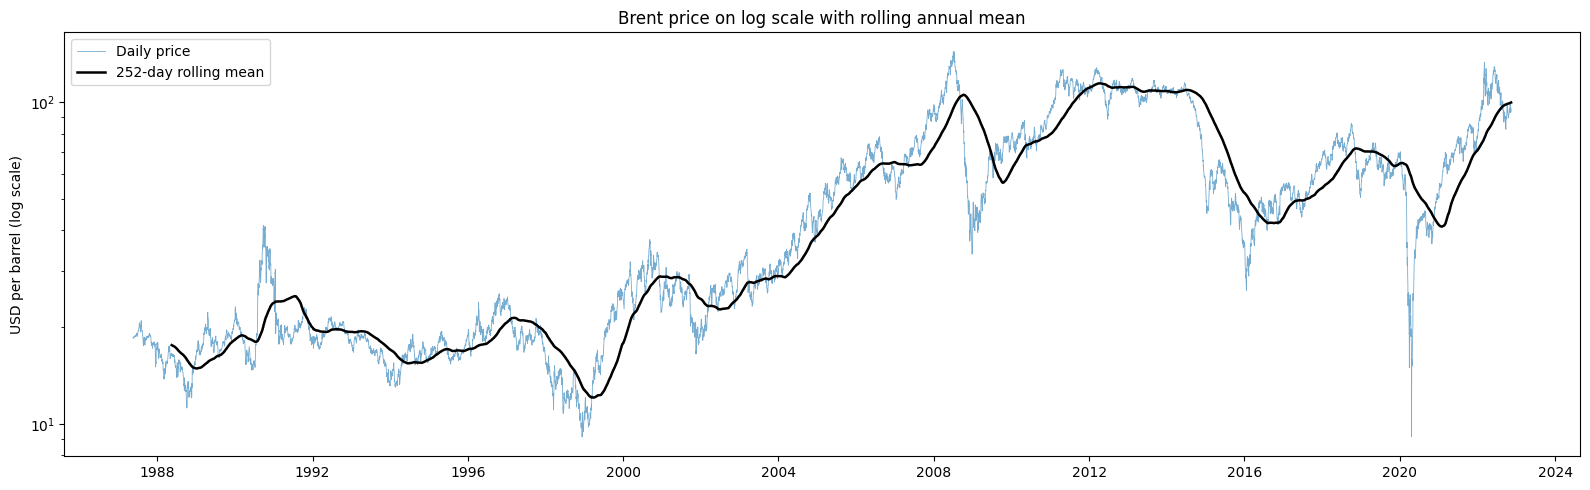

In [4]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(prices.index, prices["Price"], lw=0.6, alpha=0.6, label="Daily price")
ax.plot(prices.index, prices["Price"].rolling(252).mean(), lw=1.8, color="black",
        label="252-day rolling mean")
ax.set_yscale("log")
ax.set_ylabel("USD per barrel (log scale)")
ax.set_title("Brent price on log scale with rolling annual mean")
ax.legend()
plt.tight_layout()

## Distribution of log returns

Heavy tails relative to a Normal fit are typical of commodity returns; the
excess kurtosis below quantifies this. It matters for modeling: a Normal
likelihood is the mandated starting point, but a Student-t likelihood is a
natural robustness extension.

mean = +0.00018   std = 0.02553
skew = -1.744   excess kurtosis = 65.9
largest single-day moves:
Date
2020-04-21   -0.643699
2020-04-22    0.412023
1991-01-17   -0.361214
2020-04-02    0.301613
2020-03-09   -0.255175


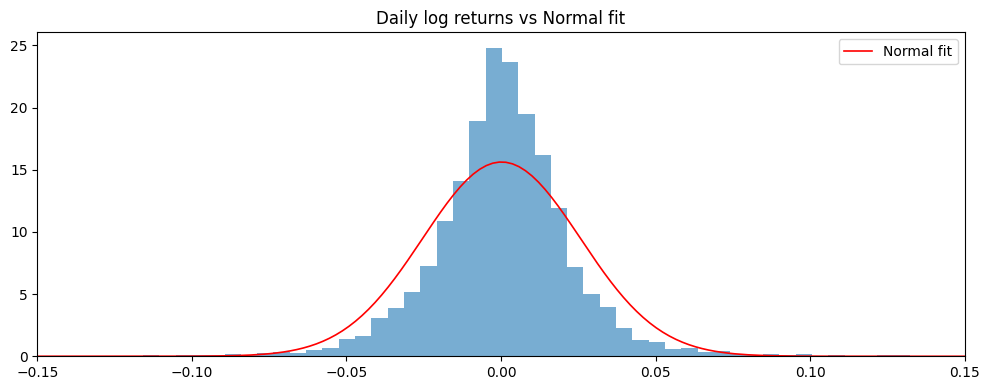

In [5]:
import numpy as np
from scipy import stats

r = prices["LogReturn"].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(r, bins=200, density=True, alpha=0.6)
x = np.linspace(r.min(), r.max(), 500)
ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r-", lw=1.2, label="Normal fit")
ax.set_xlim(-0.15, 0.15)
ax.set_title("Daily log returns vs Normal fit")
ax.legend()
plt.tight_layout()

print(f"mean = {r.mean():+.5f}   std = {r.std():.5f}")
print(f"skew = {r.skew():+.3f}   excess kurtosis = {r.kurtosis():.1f}")
print("largest single-day moves:")
print(r.reindex(r.abs().sort_values(ascending=False).index).head(5).to_string())

## Findings

- **Data:** 9,011 daily observations, 1987-05-20 to 2022-11-14, no missing
  prices after parsing; the series covers ~$9 to ~$144 per barrel.
- **Trend:** no single global trend — long persistent regimes instead
  (pre-2000 low-price era, 2003–08 run-up, 2011–14 plateau above $100,
  2014–15 collapse, 2020 COVID crash, 2022 invasion spike). A fixed-mean model
  is untenable, which is exactly the case for change point analysis.
- **Stationarity:** ADF on the price level: stat −1.99, p = 0.29 →
  non-stationary. ADF on log returns: stat −16.4, p ≈ 0 → stationary.
  **Log returns are the modeling target.**
- **Volatility:** strong clustering, with regime bursts around 1990–91 (Gulf
  War), 2008–09 (financial crisis), 2014–16 (OPEC price war), and 2020
  (COVID). Volatility shifts look at least as detectable as mean shifts.
- **Tails:** returns are violently heavy-tailed — excess kurtosis ≈ 66,
  skew −1.7, largest single-day moves −64% / +41% (both April 2020). The
  Normal likelihood is the mandated baseline; a Student-t likelihood is the
  obvious robustness extension.
- **Modeling implication:** detect change points in the *mean and volatility
  of log returns*, applied over focused windows around candidate break
  periods rather than one switch point across 35 years.

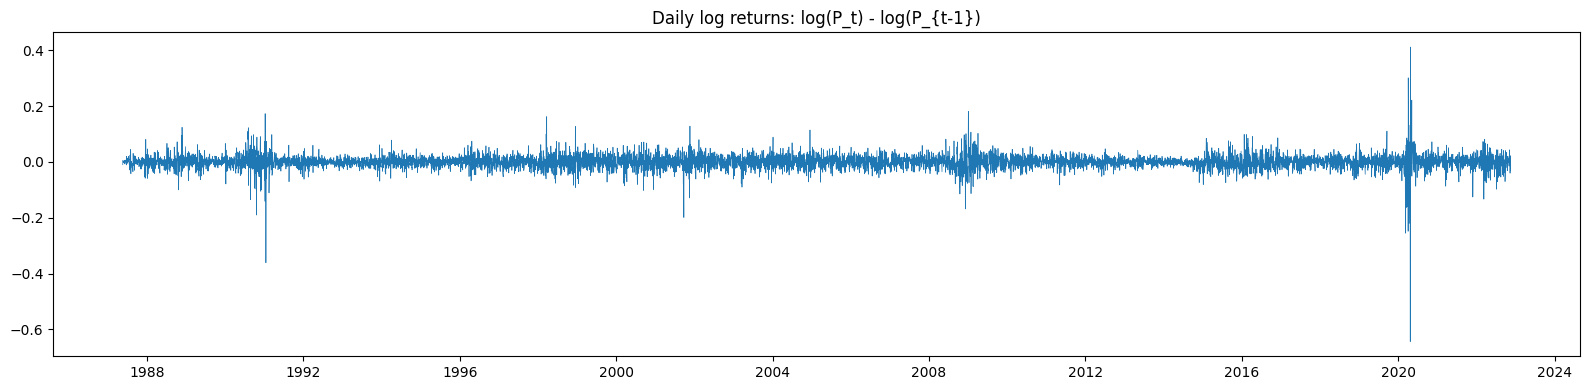

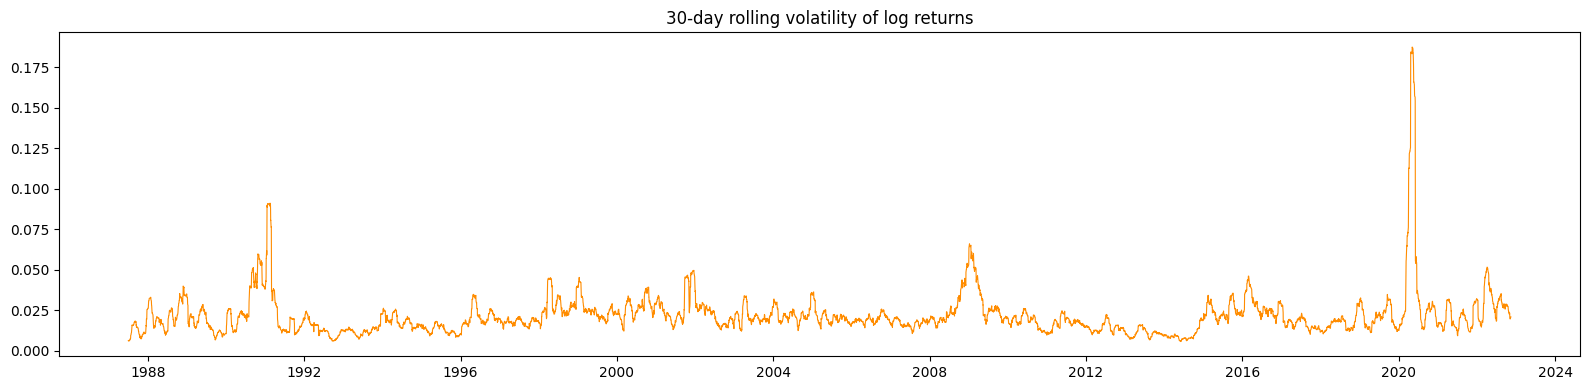

In [6]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(prices.index, prices["LogReturn"], lw=0.5)
ax.set_title("Daily log returns: log(P_t) - log(P_{t-1})")
plt.tight_layout()

# Rolling 30-day std of returns — a direct view of volatility regimes
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(prices.index, prices["LogReturn"].rolling(30).std(), lw=0.8, color="darkorange")
ax.set_title("30-day rolling volatility of log returns")
plt.tight_layout()

## Stationarity: ADF tests

Expectation: the price level is non-stationary (unit root), while log returns are
stationary — which is why the change point model targets the return series.

In [7]:
def adf_report(series, name):
    stat, pvalue, *_ = adfuller(series.dropna(), autolag="AIC")
    verdict = "stationary" if pvalue < 0.05 else "NON-stationary"
    print(f"{name:12s}  ADF stat = {stat:8.3f}   p-value = {pvalue:.4f}   -> {verdict}")

adf_report(prices["Price"], "Price")
adf_report(prices["LogReturn"], "Log returns")

Price         ADF stat =   -1.994   p-value = 0.2893   -> NON-stationary


Log returns   ADF stat =  -16.427   p-value = 0.0000   -> stationary


## Findings (fill in after running)

- **Trend:** ...
- **Stationarity:** price level non-stationary; log returns stationary → model returns.
- **Volatility:** clustering visible around ... (compare with events overlay).
- **Modeling implication:** change points in the *mean and/or volatility of log
  returns*, or mean of price within focused windows around candidate breaks.